In [1]:
import matplotlib.pylab as plt
import xarray as xr
import json

import sys
sys.path.append("../src")
import icon_grid_coarsening as igc

In [2]:
icon_grid = xr.open_dataset("grid.nc")
icon_grid['cell'] = icon_grid.cell.values
with open("../src/domains_indices.json", "r") as f:
    domains = json.load(f)
domain_cells = domains['domain03']
grid_sel = icon_grid.sel(cell=domain_cells)

In [4]:
factor = 32
assert factor % 4 == 0, "Factor must be a multiple of 4 for the coarsening to work properly."
subset_cells = grid_sel.isel(cell=slice(factor* 2 ** (2 * 4)))

In [5]:
# Create multi-level graph hierarchy
all_cells = subset_cells.cell.values

# Create coarsened levels (automatically generates multiple levels)
num_coarsening_levels = 4
coarsened_levels = igc.create_multilevel_hierarchy(
    all_cells, 
    icon_grid, 
    num_levels=num_coarsening_levels
)

# Create finest level with neighbor edges
finest_level = igc.create_finest_level(
    all_cells, 
    icon_grid, 
    subset_cells,
    triangles_for_neighbors=coarsened_levels[0]['triangles']
)

# Combine all levels (finest first, then coarsened levels)
all_levels = [finest_level] + coarsened_levels

# Print summary
print("Multi-level hierarchy created:\n")
for level in all_levels:
    print(f"{level['name']:25s} | "
          f"Nodes: {level['graph'].number_of_nodes():5d} | "
          f"Edges: {level['graph'].number_of_edges():5d}")

Multi-level hierarchy created:

Original (finest)         | Nodes:  8192 | Edges:  6144
Level 0 (1st coarsening)  | Nodes:  2048 | Edges:  1536
Level 1 (2nd coarsening)  | Nodes:   512 | Edges:   384
Level 2 (3rd coarsening)  | Nodes:   128 | Edges:    96
Level 3 (4th coarsening)  | Nodes:    32 | Edges:    24


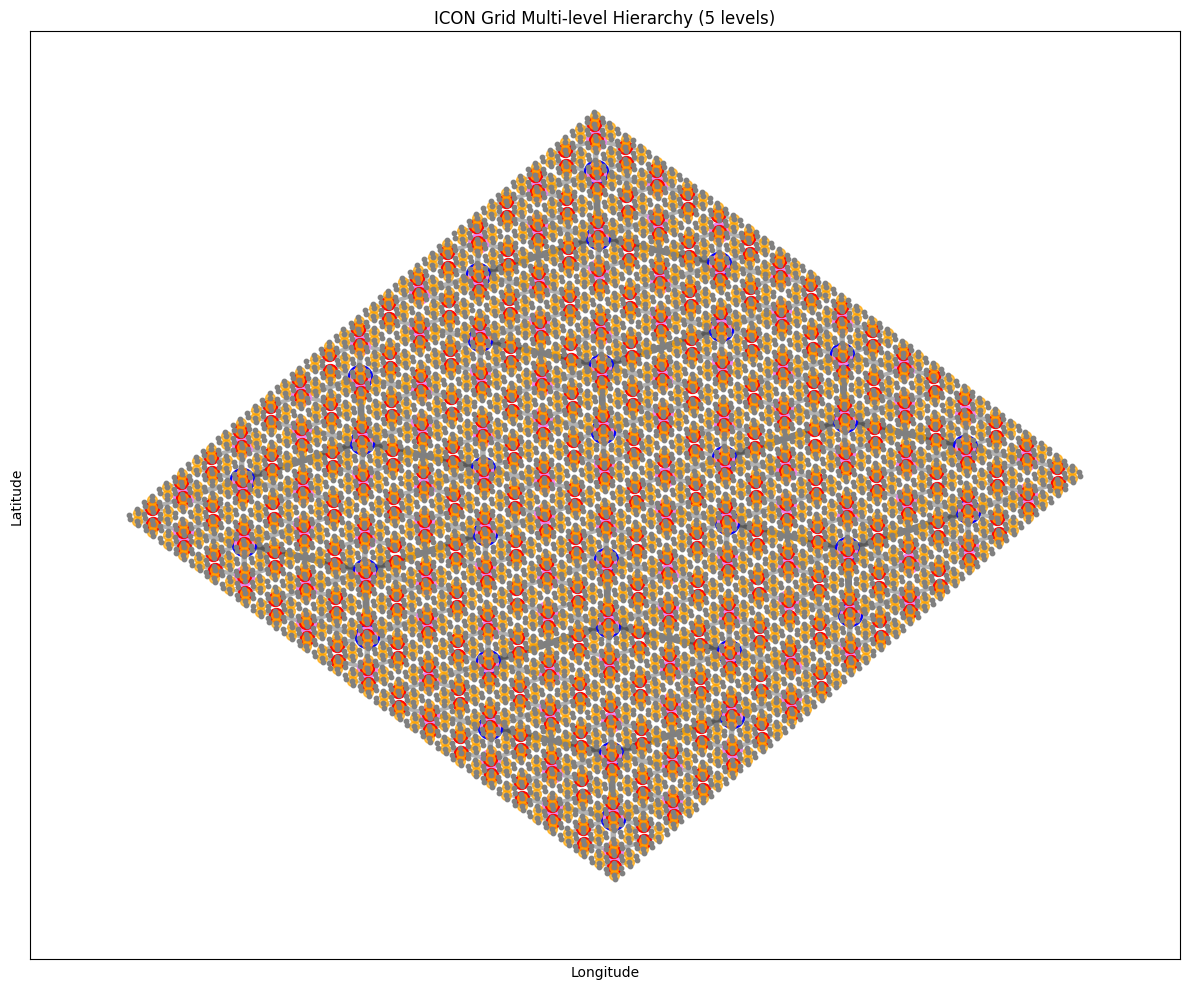

In [5]:
# Visualize all graph levels using the hierarchical data structure

# Define visualization properties for each level (coarsest to finest)
viz_properties = [
    {'node_size': 300, 'node_color': 'blue', 'edge_width': 5, 'edge_alpha': 0.5},      # Level 3
    {'node_size': 200, 'node_color': 'violet', 'edge_width': 4, 'edge_alpha': 0.3},    # Level 2
    {'node_size': 100, 'node_color': 'red', 'edge_width': 3, 'edge_alpha': 0.3},       # Level 1
    {'node_size': 50, 'node_color': 'orange', 'edge_width': 2, 'edge_alpha': 0.3, 'node_alpha': 0.7},  # Level 0
    {'node_size': 10, 'node_color': 'grey', 'edge_width': 0.5, 'edge_alpha': 0.3},     # Finest
]

# Build graphs_data from all_levels (reverse order to draw coarsest first)
graphs_data = []
for i, level in enumerate(reversed(all_levels)):
    props = viz_properties[i] if i < len(viz_properties) else {}
    graph_info = {
        'graph': level['graph'],
        'pos': level['pos'],
        **props  # Unpack visualization properties
    }
    graphs_data.append(graph_info)

fig, ax = igc.visualize_multilevel_graph(
    graphs_data,
    title=f'ICON Grid Multi-level Hierarchy ({len(all_levels)} levels)'
)
plt.show()

In [ ]:
# Save the multi-level graph hierarchy to disk
import pickle

output_path = "../data/multilevel_graph_hierarchy.pkl"

# Save the entire hierarchy
with open(output_path, 'wb') as f:
    pickle.dump(all_levels, f)

print(f"Saved {len(all_levels)} graph levels to {output_path}")

# To load later, use:
# with open(output_path, 'rb') as f:
#     loaded_levels = pickle.load(f)

## Working with the Multi-Level Hierarchy

The `all_levels` list contains all graph levels from finest to coarsest. Each level is a dictionary with:
- `graph`: NetworkX Graph object
- `pos`: Position dictionary mapping cell IDs to (lon, lat)
- `cells`: Array of cell indices at this level
- `name`: Descriptive name
- `level`: Level index (-1 for finest, 0+ for coarsened levels)

You can easily:
- Access any level: `all_levels[i]`
- Iterate over levels: `for level in all_levels: ...`
- Extend to more levels by changing `num_coarsening_levels`
- Customize coarsening with `coarsening_configs` parameter

In [6]:
# Example: Access specific levels easily
print("Example usage of the hierarchical data structure:\n")

# Access finest level
print(f"Finest level has {all_levels[0]['graph'].number_of_nodes()} nodes")

# Access a specific coarsening level
print(f"Level 2 has {all_levels[3]['graph'].number_of_nodes()} nodes")

# Iterate and compute statistics
print("\nNode count reduction ratios:")
for i in range(len(all_levels) - 1):
    n1 = all_levels[i]['graph'].number_of_nodes()
    n2 = all_levels[i + 1]['graph'].number_of_nodes()
    ratio = n1 / n2 if n2 > 0 else 0
    print(f"  {all_levels[i]['name']} → {all_levels[i+1]['name']}: {ratio:.2f}x reduction")

Example usage of the hierarchical data structure:

Finest level has 8192 nodes
Level 2 has 128 nodes

Node count reduction ratios:
  Original (finest) → Level 0 (1st coarsening): 4.00x reduction
  Level 0 (1st coarsening) → Level 1 (2nd coarsening): 4.00x reduction
  Level 1 (2nd coarsening) → Level 2 (3rd coarsening): 4.00x reduction
  Level 2 (3rd coarsening) → Level 3 (4th coarsening): 4.00x reduction


In [8]:
# Example: Easily extend to more coarsening levels
# Just change num_coarsening_levels to create more levels automatically

# Create a hierarchy with 6 levels instead of 4
extended_levels = igc.create_multilevel_hierarchy(
    all_cells, 
    icon_grid, 
    num_levels=5  # Extend to 6 levels
)

extended_finest = igc.create_finest_level(
    all_cells, 
    icon_grid, 
    subset_cells,
    triangles_for_neighbors=extended_levels[0]['triangles']
)

all_extended_levels = [extended_finest] + extended_levels

print(f"Extended hierarchy with {len(all_extended_levels)} total levels:\n")
for level in all_extended_levels:
    print(f"{level['name']:30s} | Nodes: {level['graph'].number_of_nodes():5d}")

Extended hierarchy with 6 total levels:

Original (finest)              | Nodes:  8192
Level 0 (1st coarsening)       | Nodes:  2048
Level 1 (2nd coarsening)       | Nodes:   512
Level 2 (3rd coarsening)       | Nodes:   128
Level 3 (4th coarsening)       | Nodes:    32
Level 4 (5th coarsening)       | Nodes:     8


In [3]:
import pickle
output_path = "../data/multilevel_graph_hierarchy.domain03.pkl"
with open(output_path, 'rb') as f:
    loaded_levels = pickle.load(f)

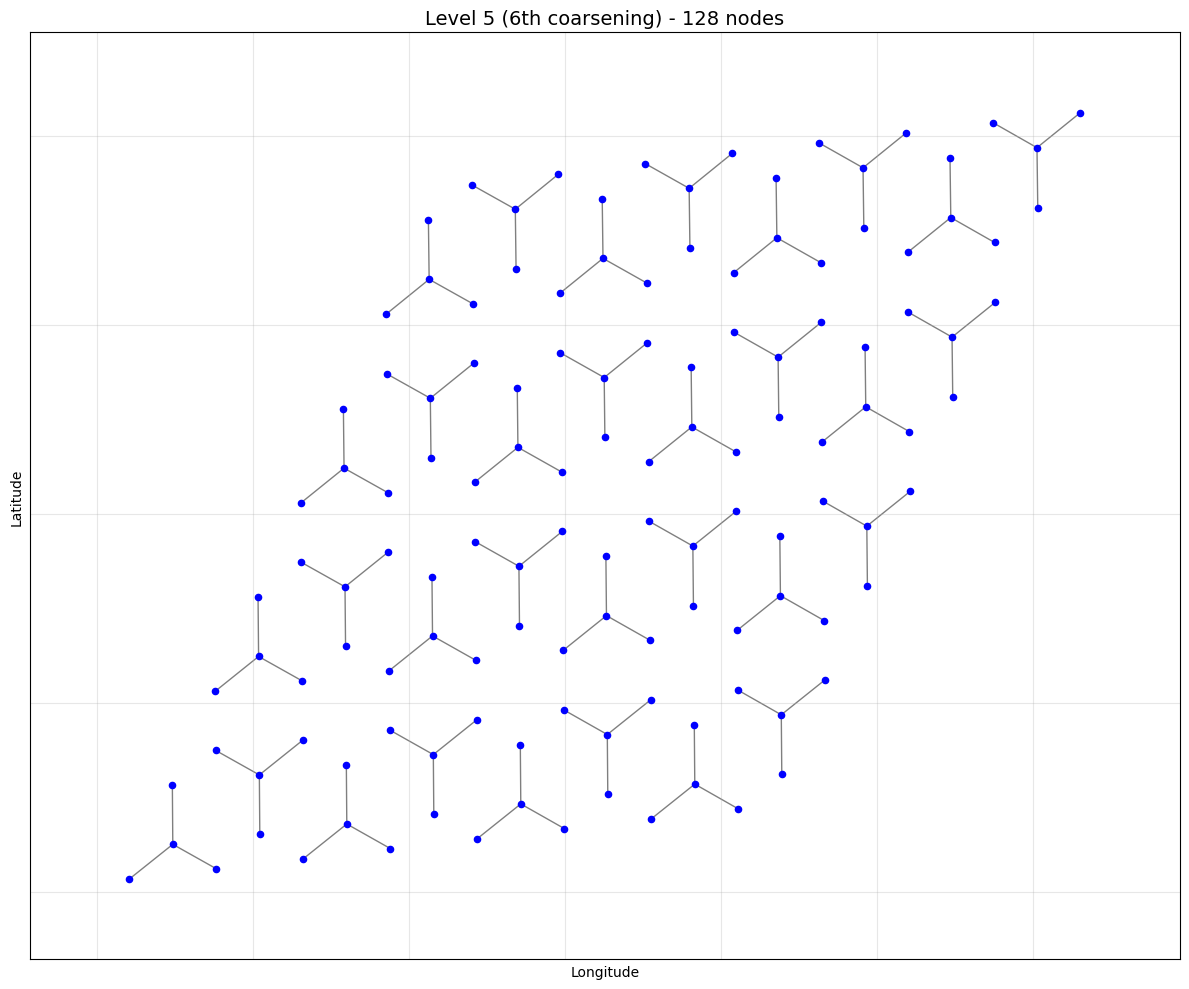

Coarsest level: Level 5 (6th coarsening)
Number of nodes: 128
Number of edges: 96


In [38]:
import networkx as nx

# Visualize only the coarsest level from loaded_levels
coarsest_level = loaded_levels[6]

# Create a simple visualization of just the coarsest level
fig, ax = plt.subplots(figsize=(12, 10))

# Extract graph and positions
G = coarsest_level['graph']
pos = coarsest_level['pos']

# Draw the graph
nx.draw_networkx_nodes(G, pos, node_size=20, node_color='blue', ax=ax)
nx.draw_networkx_edges(G, pos, width=1, alpha=0.5, ax=ax)

ax.set_title(f"{coarsest_level['name']} - {G.number_of_nodes()} nodes", fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Coarsest level: {coarsest_level['name']}")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

In [17]:
## Loading data and coarsen it along the graph

In [18]:
pred = xr.open_dataset("../evals/rain_mse.zarr", engine="zarr")
pred_single_time_and_var = pred.isel(start_time=0, elapsed_forecast_duration=0).sel(state_feature='t_2m')
pred_single_time_and_var = pred_single_time_and_var.rename({'grid_index': 'cell'})

In [19]:
level_cells = list(G.nodes.keys())

In [20]:
coarsen = int(coarsest_level['name'].split(" ")[1])+1
level_data = pred_single_time_and_var.state.values.reshape(-1, 4**coarsen).mean(axis=-1)
assert len(level_data) == len(level_cells)

In [21]:
nx.set_node_attributes(G, dict(zip(level_cells, level_data)), 'value')

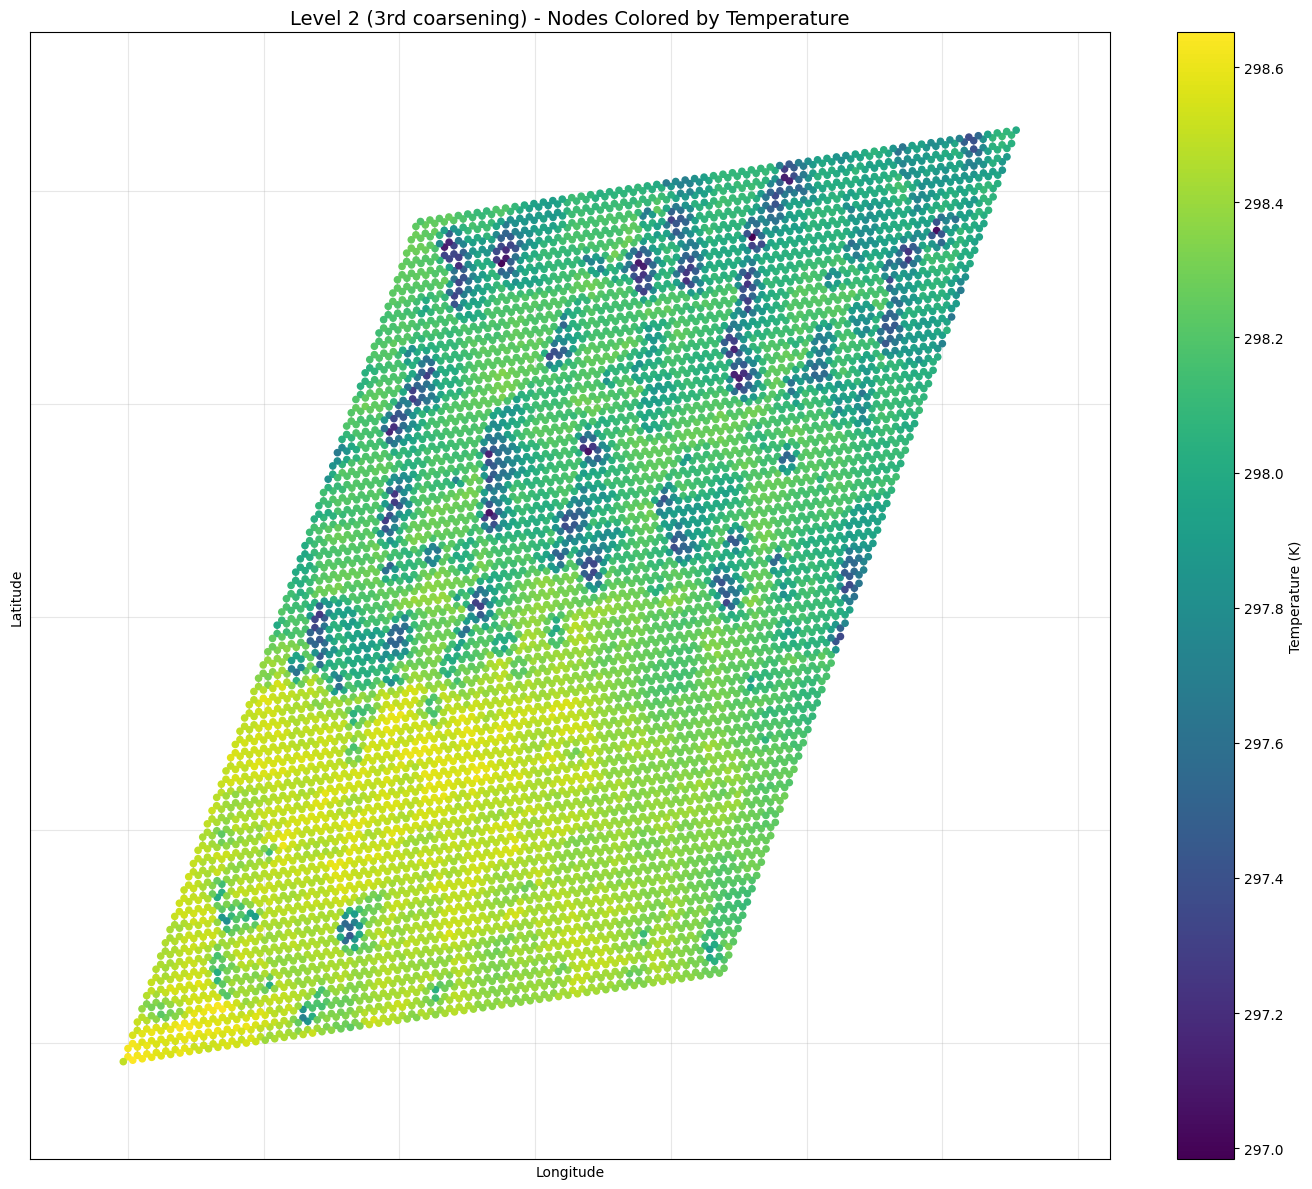

In [22]:
# Visualize the coarsest level graph with nodes colored by their values
fig, ax = plt.subplots(figsize=(14, 12))

# Extract graph and positions
pos = coarsest_level['pos']

# Create a list of node values in the same order as nodes in the graph
node_values = [G.nodes[node].get('value', 0) for node in G.nodes()]

# Draw the graph with nodes colored by their values
nodes = nx.draw_networkx_nodes(
    G, pos, 
    node_color=node_values,
    node_size=20,
    cmap='viridis',
    ax=ax
)

nx.draw_networkx_edges(G, pos, width=1, alpha=0.3, ax=ax)

ax.set_title(f"{coarsest_level['name']} - Nodes Colored by Temperature", fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(nodes, ax=ax, label='Temperature (K)')

plt.tight_layout()
plt.show()

In [23]:
# Check how many disconnected components exist
num_components = nx.number_connected_components(G)
components = list(nx.connected_components(G))

print(f"Number of disconnected components: {num_components}")
print(f"Component sizes: {[len(c) for c in components[:10]]}...")  # Show first 10

Number of disconnected components: 2048
Component sizes: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]...


In [39]:
import numpy as np
# Make a copy of the graph to modify
G_connected = G.copy()

# Connect the components - use more neighbors for better connectivity
G_connected, n_edges = igc.connect_graph_components(G_connected, pos, k_neighbors=3, max_distance=0.2)

print(f"Edges added: {n_edges}")
print(f"Components before: {nx.number_connected_components(G)}")
print(f"Components after: {nx.number_connected_components(G_connected)}")
print(f"Edges before: {G.number_of_edges()}")
print(f"Edges after: {G_connected.number_of_edges()}")

Edges added: 80
Components before: 32
Components after: 1
Edges before: 96
Edges after: 176


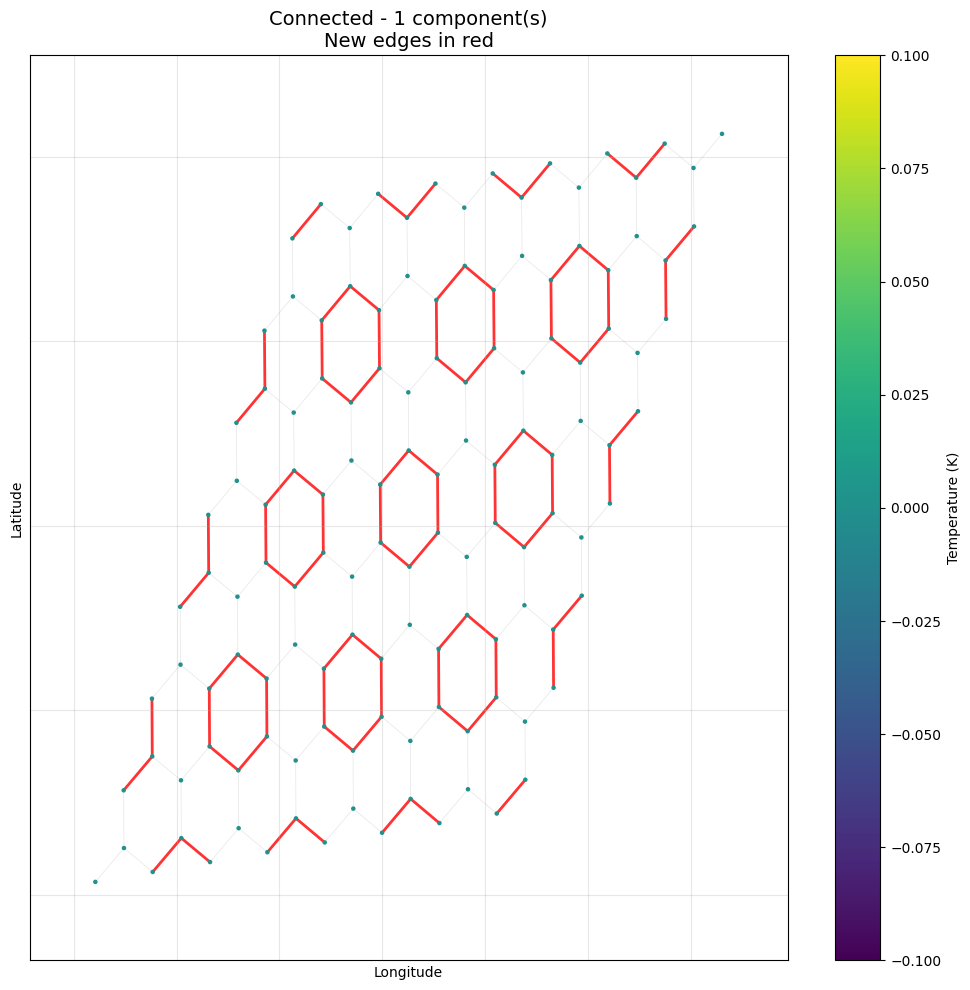

In [41]:
# Visualize the connected graph with temperature coloring
fig, ax2 = plt.subplots(1, 1, figsize=(10,10))

# Get node values for coloring
node_values = [G_connected.nodes[node].get('value', 0) for node in G_connected.nodes()]

# Right plot: Connected graph with new edges highlighted
# Draw old edges in gray
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.2, edge_color='gray', ax=ax2)

# Draw new edges in red
new_edges = [(u, v) for u, v in G_connected.edges() if not G.has_edge(u, v)]
nx.draw_networkx_edges(G_connected, pos, edgelist=new_edges, width=2, alpha=0.8, edge_color='red', ax=ax2)

# Draw nodes on top
nodes2 = nx.draw_networkx_nodes(
    G_connected, pos, 
    node_color=node_values,
    node_size=5,
    cmap='viridis',
    ax=ax2
)

ax2.set_title(f"Connected - {nx.number_connected_components(G_connected)} component(s)\nNew edges in red", fontsize=14)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.grid(True, alpha=0.3)

# Add shared colorbar
cbar = plt.colorbar(nodes2, label='Temperature (K)')

plt.tight_layout()
plt.show()